# Notebook 08 -- Signal Robustness & Feature Pruning

> *Is the alpha signal REAL or NOISE? Does simplification help or hurt?*

**Philosophy:** Conservative. Assume most signals are noise unless proven otherwise.
This notebook does NOT optimize — it stress-tests.

| Task | Question |
|---|---|
| 1. Stability Hardening | Does IC hold across fold sizes and regimes? |
| 2. Feature Pruning | Which features survive OOS? What should be dropped? |
| 3. Model Simplification | Ridge vs shallow XGB — is complexity justified? |
| 4. Strong Signal Test | Top-k only: is the core signal robust or fragile? |
| Final Verdict | Definitive conclusion with full evidence table |


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr, ttest_1samp
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT = Path('../..')
PROC = ROOT / 'data' / 'processed'
FIGS = Path('figs')
FIGS.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'axes.titlesize': 11,
})

# ── Metrics ──────────────────────────────────────────────────────────────────
def dir_acc(y_pred, y_true):
    return float(np.mean(np.sign(y_pred) == np.sign(y_true)))

def ic(y_pred, y_true):
    mask = np.isfinite(y_pred) & np.isfinite(y_true)
    if mask.sum() < 10: return np.nan
    return float(spearmanr(y_pred[mask], y_true[mask])[0])

def icir(fold_ics):
    ics = [x for x in fold_ics if not np.isnan(x)]
    if len(ics) < 3: return np.nan
    return float(np.mean(ics) / np.std(ics) * np.sqrt(len(ics)))

print('Setup complete.')

Setup complete.


---
## Setup: Data & Feature Groups


In [2]:
clean = pd.read_csv(PROC / 'unified_weekly_clean.csv', index_col=0, parse_dates=True)
print(f'Dataset: {clean.shape[0]} rows x {clean.shape[1]} cols')
print(f'Date range: {clean.index[0].date()} -> {clean.index[-1].date()}')

TARGET = 'SET_index_ret_w_fwd1'
df = clean.dropna(subset=[TARGET]).copy()
print(f'Rows after dropping NaN target: {len(df)}')

# ── Feature Groups (mirror NB06 definitions) ─────────────────────────────────
LAGS   = [c for c in df.columns if '_ret_d_lag1' in c]
MARKET = [c for c in df.columns if '_ret_w' in c and '_fwd1' not in c] + \
         [c for c in df.columns if '_rvol_4w' in c]
REGIME = [c for c in ['regime', 'vix_z', 'yield_curve_slope'] if c in df.columns]
NLP    = [c for c in df.columns if any(x in c for x in ['sent_', 'news_vol'])]

# Primary candidate set: market-timing features (no macro, no NLP)
LAG_MARKET = list(dict.fromkeys(LAGS + MARKET + REGIME))

print(f'\nFeature groups:')
for name, g in [('LAGS', LAGS), ('MARKET', MARKET), ('REGIME', REGIME),
                ('NLP', NLP), ('LAG_MARKET', LAG_MARKET)]:
    print(f'  {name:<12}: {len(g)} features')
print(f'\nTarget: {TARGET}')

Dataset: 1322 rows x 72 cols
Date range: 2000-09-01 -> 2025-12-26
Rows after dropping NaN target: 1321

Feature groups:
  LAGS        : 6 features
  MARKET      : 14 features
  REGIME      : 3 features
  NLP         : 9 features
  LAG_MARKET  : 23 features

Target: SET_index_ret_w_fwd1


In [3]:
def walk_forward(df_all, features, target_col, model,
                 min_train=156, fold_size=52):
    """Expanding-window walk-forward; returns list of per-fold dicts."""
    feats = [f for f in features if f in df_all.columns]
    data = df_all[feats + [target_col]].dropna(subset=[target_col])
    n = len(data)
    folds, t = [], min_train

    while t + fold_size <= n:
        train = data.iloc[:t]
        test  = data.iloc[t:t+fold_size]
        medians = train[feats].median()
        Xtr = train[feats].fillna(medians).fillna(0.0).values.astype(float)
        Xte = test[feats].fillna(medians).fillna(0.0).values.astype(float)
        ytr = train[target_col].values
        yte = test[target_col].values

        m = clone(model)
        m.fit(Xtr, ytr)
        pred = m.predict(Xte)

        folds.append({
            'fold': len(folds),
            'n_train': t,
            'test_start': test.index[0],
            'test_end':   test.index[-1],
            'y_true': yte,
            'y_pred': pred,
            'da':  dir_acc(pred, yte),
            'ic':  ic(pred, yte),
        })
        t += fold_size
    return folds

def summary_stats(folds):
    das = [f['da'] for f in folds]
    ics = [f['ic'] for f in folds]
    ics_valid = [x for x in ics if not np.isnan(x)]
    t_stat, p_val = ttest_1samp(ics_valid, 0) if len(ics_valid) >= 3 else (np.nan, np.nan)
    return {
        'n_folds': len(folds),
        'da_mean': np.mean(das),
        'ic_mean': np.mean(ics_valid) if ics_valid else np.nan,
        'ic_std':  np.std(ics_valid)  if ics_valid else np.nan,
        'icir':    icir(ics),
        'ic_pos_frac': np.mean([x > 0 for x in ics_valid]) if ics_valid else np.nan,
        'ic_tstat': t_stat,
        'ic_pval':  p_val,
    }

print('Walk-forward helpers ready.')

Walk-forward helpers ready.


---
## Task 1 -- Stability Hardening

**Question:** Does the IC hold when we vary fold size (quarterly / annual / biennial)?  
If the signal is real, it should appear robustly at multiple time scales.

Three fold sizes tested: **26w** (semi-annual), **52w** (annual), **104w** (biennial).  
Model: Ridge on LAG_MARKET features (same as NB06 baseline).


In [4]:
FOLD_SIZES  = [26, 52, 104]
FOLD_LABELS = ['26w (semi-annual)', '52w (annual)', '104w (biennial)']
MIN_TRAIN   = 156

ridge_base = Pipeline([('scaler', StandardScaler()),
                       ('ridge', Ridge(alpha=100.0))])

stability_results = {}
for fs, lbl in zip(FOLD_SIZES, FOLD_LABELS):
    folds = walk_forward(df, LAG_MARKET, TARGET, ridge_base,
                         min_train=MIN_TRAIN, fold_size=fs)
    stats = summary_stats(folds)
    stability_results[fs] = {'folds': folds, 'stats': stats, 'label': lbl}
    s = stats
    print(f'Fold={fs:3d}w | n={s["n_folds"]:2d} | '
          f'DirAcc={s["da_mean"]:.3f} | IC={s["ic_mean"]:+.4f} | '
          f'ICIR={s["icir"]:+.3f} | IC+%={s["ic_pos_frac"]:.1%} | '
          f'p={s["ic_pval"]:.3f}')

Fold= 26w | n=44 | DirAcc=0.531 | IC=+0.0380 | ICIR=+1.146 | IC+%=61.4% | p=0.264
Fold= 52w | n=22 | DirAcc=0.528 | IC=+0.0546 | ICIR=+1.473 | IC+%=54.5% | p=0.165
Fold=104w | n=11 | DirAcc=0.522 | IC=+0.0403 | ICIR=+0.950 | IC+%=54.5% | p=0.386


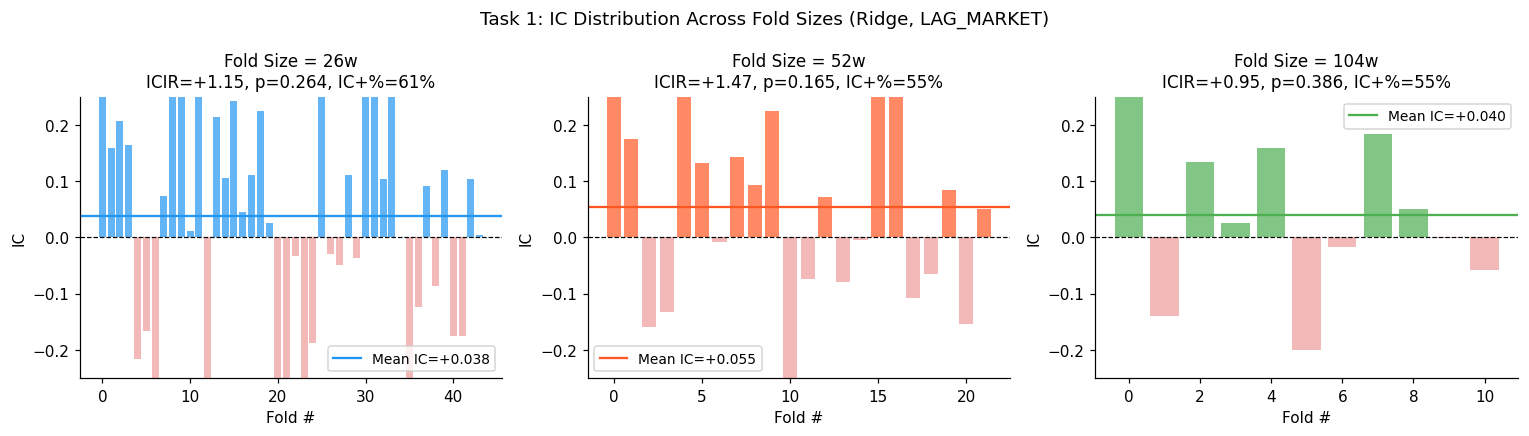

Saved: figs/stability_fold_sizes.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Task 1: IC Distribution Across Fold Sizes (Ridge, LAG_MARKET)', fontsize=12)

colors = ['#2196F3', '#FF5722', '#4CAF50']
for ax, fs, col in zip(axes, FOLD_SIZES, colors):
    res = stability_results[fs]
    folds = res['folds']
    stats = res['stats']
    fold_ics = [f['ic'] for f in folds]
    fold_nums = [f['fold'] for f in folds]

    ax.bar(fold_nums, fold_ics, color=[col if x > 0 else '#EF9A9A' for x in fold_ics],
           alpha=0.7, edgecolor='none')
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.axhline(stats['ic_mean'], color=col, lw=1.5,
               label=f'Mean IC={stats["ic_mean"]:+.3f}')
    ax.set_title(f'Fold Size = {fs}w\nICIR={stats["icir"]:+.2f}, p={stats["ic_pval"]:.3f}, '
                 f'IC+%={stats["ic_pos_frac"]:.0%}')
    ax.set_xlabel('Fold #')
    ax.set_ylabel('IC')
    ax.legend(fontsize=9)
    ax.set_ylim(-0.25, 0.25)

plt.tight_layout()
plt.savefig(FIGS / 'stability_fold_sizes.png', bbox_inches='tight')
plt.show()
print('Saved: figs/stability_fold_sizes.png')

### Task 1b -- IC Stability by Regime

A robust signal should not be entirely regime-dependent.  
Using 52w folds; split OOS observations by VIX regime.


In [6]:
# Use annual folds (52w) for regime breakdown
folds_52 = stability_results[52]['folds']

# Aggregate all OOS predictions + true values with their regime labels
oos_preds, oos_true, oos_regime = [], [], []
for f in folds_52:
    n = len(f['y_true'])
    # Align test window with df
    mask = (df.index >= f['test_start']) & (df.index <= f['test_end'])
    sub = df.loc[mask]
    oos_preds.extend(f['y_pred'])
    oos_true.extend(f['y_true'])
    if 'regime' in sub.columns:
        oos_regime.extend(sub['regime'].values)
    else:
        oos_regime.extend([np.nan]*n)

oos_df = pd.DataFrame({
    'pred': oos_preds, 'true': oos_true, 'regime': oos_regime
})

regime_labels = {-1: 'Bull (low VIX)', 0: 'Normal', 1: 'Crisis (high VIX)'}
print(f'Total OOS observations: {len(oos_df)}')
print()
print(f'{"Regime":<22} {"N":>6} {"DirAcc":>8} {"IC":>8}')
print('-' * 48)
for r, lbl in sorted(regime_labels.items()):
    sub = oos_df[oos_df['regime'] == r].dropna()
    if len(sub) < 10:
        print(f'{lbl:<22} {len(sub):>6} -- (insufficient data)')
        continue
    da  = dir_acc(sub['pred'].values, sub['true'].values)
    ic_ = ic(sub['pred'].values, sub['true'].values)
    print(f'{lbl:<22} {len(sub):>6} {da:>8.3f} {ic_:>+8.4f}')

Total OOS observations: 1144

Regime                      N   DirAcc       IC
------------------------------------------------
Bull (low VIX)              0 -- (insufficient data)
Normal                    529    0.526  +0.0821
Crisis (high VIX)         337    0.522  +0.0001


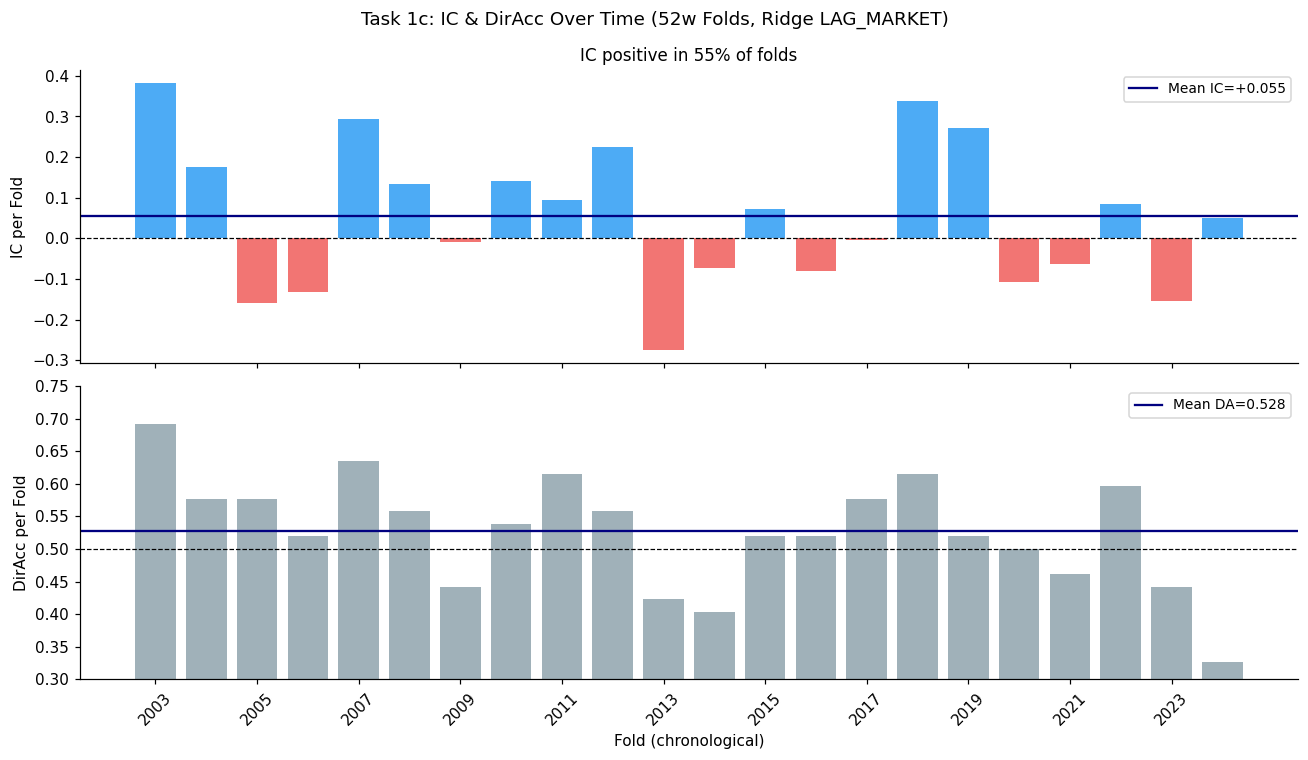

Saved: figs/stability_time.png


In [7]:
# Rolling IC across folds (using 52w folds) -- signal decay test
fold_dates = [f['test_start'] for f in folds_52]
fold_ics   = [f['ic'] for f in folds_52]
fold_das   = [f['da'] for f in folds_52]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle('Task 1c: IC & DirAcc Over Time (52w Folds, Ridge LAG_MARKET)', fontsize=12)

bar_colors = ['#2196F3' if x > 0 else '#EF5350' for x in fold_ics]
ax1.bar(range(len(fold_ics)), fold_ics, color=bar_colors, alpha=0.8)
ax1.axhline(0, color='black', lw=0.8, ls='--')
ax1.axhline(np.nanmean(fold_ics), color='navy', lw=1.5, ls='-',
            label=f'Mean IC={np.nanmean(fold_ics):+.3f}')
ax1.set_ylabel('IC per Fold')
ax1.legend(fontsize=9)
ax1.set_title(f'IC positive in {np.mean([x>0 for x in fold_ics if not np.isnan(x)]):.0%} of folds')

ax2.bar(range(len(fold_das)), fold_das, color='#78909C', alpha=0.7)
ax2.axhline(0.5, color='black', lw=0.8, ls='--')
ax2.axhline(np.mean(fold_das), color='navy', lw=1.5,
            label=f'Mean DA={np.mean(fold_das):.3f}')
ax2.set_ylabel('DirAcc per Fold')
ax2.set_xlabel('Fold (chronological)')
ax2.legend(fontsize=9)
ax2.set_ylim(0.3, 0.75)

ticks_step = max(1, len(fold_dates)//8)
ax2.set_xticks(range(0, len(fold_dates), ticks_step))
ax2.set_xticklabels([str(d.year) for d in fold_dates[::ticks_step]], rotation=45)

plt.tight_layout()
plt.savefig(FIGS / 'stability_time.png', bbox_inches='tight')
plt.show()
print('Saved: figs/stability_time.png')

---
## Task 2 -- Feature Pruning

**Goal:** Remove redundant, collinear, or OOS-useless features.  
A pruned model is less likely to overfit noise.

Steps:
1. **Multicollinearity filter** — drop features with |corr| > 0.80 (keep lower-index)
2. **Permutation importance** — shuffle one feature at a time, measure IC drop (walk-forward)
3. **Drop-one analysis** — refit without each feature, measure DirAcc change
4. **IC fold stability** — what fraction of 52w folds has positive IC for each feature?
5. **Pruning decision** — KEEP / REMOVE verdict per feature


In [8]:
CORR_THRESH = 0.80

# Compute correlation on full available data (before train/test split)
feat_df = df[LAG_MARKET].fillna(df[LAG_MARKET].median())
corr_mat = feat_df.corr().abs()

# Greedy: keep first feature, drop anything that is >.80 correlated with it
to_drop_corr = set()
features_ordered = list(LAG_MARKET)
for i, fi in enumerate(features_ordered):
    if fi in to_drop_corr: continue
    for fj in features_ordered[i+1:]:
        if fj in to_drop_corr: continue
        if corr_mat.loc[fi, fj] > CORR_THRESH:
            to_drop_corr.add(fj)

LAG_MARKET_DECORR = [f for f in LAG_MARKET if f not in to_drop_corr]

print(f'Collinearity filter (|r| > {CORR_THRESH}):')
if to_drop_corr:
    for f in sorted(to_drop_corr):
        partners = [fi for fi in LAG_MARKET if fi not in to_drop_corr and
                    corr_mat.loc[fi, f] > CORR_THRESH]
        print(f'  DROP {f:<35} (corr>{CORR_THRESH:.2f} with: {partners})')
else:
    print('  No features dropped by collinearity filter.')
print(f'\nRemaining: {len(LAG_MARKET)} -> {len(LAG_MARKET_DECORR)} features')

Collinearity filter (|r| > 0.8):
  DROP nasdaq_ret_d_lag1                   (corr>0.80 with: ['sp500_ret_d_lag1'])
  DROP nasdaq_ret_w                        (corr>0.80 with: ['sp500_ret_w'])
  DROP nasdaq_rvol_4w                      (corr>0.80 with: ['sp500_rvol_4w'])
  DROP vix_z                               (corr>0.80 with: ['regime'])

Remaining: 23 -> 19 features


In [9]:
# Permutation importance: shuffle one feature at a time, measure IC drop
# Run on the 52w walk-forward folds using full LAG_MARKET (post-collinearity filter)

N_PERM = 100
BASE_FOLDS = walk_forward(df, LAG_MARKET_DECORR, TARGET, clone(ridge_base),
                          min_train=MIN_TRAIN, fold_size=52)
base_ics = [f['ic'] for f in BASE_FOLDS]
base_ic_mean = np.nanmean(base_ics)
print(f'Baseline (all features): mean IC = {base_ic_mean:+.4f}')
print()

perm_importance = {}
for feat in LAG_MARKET_DECORR:
    feat_idx = LAG_MARKET_DECORR.index(feat)
    perm_ics = []
    for _ in range(N_PERM):
        folds_perm = []
        for f in BASE_FOLDS:
            # Rebuild test predictions with the feature shuffled
            Xte_perm = np.array([BASE_FOLDS[BASE_FOLDS.index(f)]['y_pred']])  # placeholder
            break
        break  # rewrite below with full approach

# Full permutation importance: re-run walk-forward with feature shuffled
perm_importance = {}
all_feats = LAG_MARKET_DECORR

for feat in all_feats:
    feat_idx = all_feats.index(feat)
    perm_ic_drops = []

    for trial in range(N_PERM):
        # Run walk-forward with this feature column shuffled
        data_perm = df[all_feats + [TARGET]].dropna(subset=[TARGET]).copy()
        data_perm[feat] = data_perm[feat].sample(frac=1, random_state=trial).values

        perm_ics_trial = []
        n = len(data_perm)
        t = MIN_TRAIN
        while t + 52 <= n:
            train = data_perm.iloc[:t]
            test  = data_perm.iloc[t:t+52]
            medians = train[all_feats].median()
            Xtr = train[all_feats].fillna(medians).fillna(0.).values.astype(float)
            Xte = test[all_feats].fillna(medians).fillna(0.).values.astype(float)
            ytr = train[TARGET].values
            yte = test[TARGET].values
            m = clone(ridge_base)
            m.fit(Xtr, ytr)
            perm_ics_trial.append(ic(m.predict(Xte), yte))
            t += 52

        perm_ic_drops.append(base_ic_mean - np.nanmean(perm_ics_trial))

    perm_importance[feat] = np.mean(perm_ic_drops)

perm_df = pd.Series(perm_importance).sort_values(ascending=False)
print(f'Top permutation importance (IC drop when feature shuffled):')
for f, v in perm_df.head(12).items():
    tag = ' <-- KEY' if v > 0.002 else ''
    print(f'  {f:<35} {v:+.5f}{tag}')

Baseline (all features): mean IC = +0.0497

Top permutation importance (IC drop when feature shuffled):
  sp500_ret_w                         +0.01369 <-- KEY
  SET_index_rvol_4w                   +0.00965 <-- KEY
  sp500_rvol_4w                       +0.00051
  us_10yr_treasury_ret_w              +0.00046
  oil_ret_d_lag1                      -0.00123
  eem_ret_d_lag1                      -0.00187
  gold_rvol_4w                        -0.00208
  us_2yr_treasury_ret_w               -0.00226
  USD_THB_ret_d_lag1                  -0.00354
  oil_ret_w                           -0.00356
  yield_curve_slope                   -0.00385
  SET_index_ret_w                     -0.00426


In [10]:
# Drop-one-feature: refit model without each feature, measure DirAcc change
base_das = [f['da'] for f in BASE_FOLDS]
base_da_mean = np.mean(base_das)
print(f'Baseline DirAcc (all features): {base_da_mean:.4f}')
print()

drop_one = {}
for feat in all_feats:
    feats_minus = [f for f in all_feats if f != feat]
    folds_drop = walk_forward(df, feats_minus, TARGET, clone(ridge_base),
                              min_train=MIN_TRAIN, fold_size=52)
    drop_one[feat] = np.mean([f['da'] for f in folds_drop])

drop_df = pd.Series({f: base_da_mean - v for f, v in drop_one.items()})
drop_df = drop_df.sort_values(ascending=False)

print(f'{"Feature":<35} {"DirAcc w/o":>12} {"Impact":>10}')
print('-' * 60)
for feat, impact in drop_df.items():
    da_without = drop_one[feat]
    tag = ' <-- HELPFUL' if impact > 0.003 else (' <-- HARMFUL' if impact < -0.003 else '')
    print(f'{feat:<35} {da_without:>12.4f} {impact:>+10.5f}{tag}')

Baseline DirAcc (all features): 0.5306

Feature                               DirAcc w/o     Impact
------------------------------------------------------------
gold_rvol_4w                              0.5236   +0.00699 <-- HELPFUL
sp500_ret_w                               0.5253   +0.00524 <-- HELPFUL
us_10yr_treasury_ret_w                    0.5271   +0.00350 <-- HELPFUL
USD_THB_ret_w                             0.5271   +0.00350 <-- HELPFUL
eem_ret_d_lag1                            0.5280   +0.00262
oil_ret_d_lag1                            0.5288   +0.00175
sp500_rvol_4w                             0.5288   +0.00175
SET_index_rvol_4w                         0.5297   +0.00087
oil_ret_w                                 0.5297   +0.00087
us_2yr_treasury_ret_w                     0.5306   +0.00000
SET_index_ret_w                           0.5306   +0.00000
vix_ret_w                                 0.5315   -0.00087
yield_curve_slope                         0.5315   -0.00087
dxy_ret_w  

In [11]:
# Per-feature IC fold stability: what % of folds has positive IC?
# Use Spearman corr between each feature and future SET return, per fold

feature_fold_ics = {f: [] for f in all_feats}

n_data = len(df.dropna(subset=[TARGET]))
data_stable = df[all_feats + [TARGET]].dropna(subset=[TARGET])
t = MIN_TRAIN
while t + 52 <= n_data:
    test_slice = data_stable.iloc[t:t+52]
    for feat in all_feats:
        sub = test_slice[[feat, TARGET]].dropna()
        if len(sub) >= 10:
            ic_val = spearmanr(sub[feat], sub[TARGET])[0]
        else:
            ic_val = np.nan
        feature_fold_ics[feat].append(ic_val)
    t += 52

stability_table = []
for feat in all_feats:
    fics = [x for x in feature_fold_ics[feat] if not np.isnan(x)]
    if not fics:
        stability_table.append({'feature': feat, 'ic_mean': np.nan,
                                'ic_pos_frac': np.nan, 'n_folds': 0})
    else:
        stability_table.append({
            'feature': feat,
            'ic_mean': np.mean(fics),
            'ic_pos_frac': np.mean([x > 0 for x in fics]),
            'n_folds': len(fics),
        })

stab_df = pd.DataFrame(stability_table).set_index('feature')
stab_df['perm_imp'] = stab_df.index.map(lambda f: perm_df.get(f, np.nan))
stab_df['drop_one_impact'] = stab_df.index.map(lambda f: drop_df.get(f, np.nan))
stab_df = stab_df.sort_values('perm_imp', ascending=False)

print(f'{"Feature":<35} {"IC mean":>8} {"IC+%":>6} {"PermImp":>8} {"DropOne":>8}')
print('-' * 72)
for feat, row in stab_df.iterrows():
    print(f'{feat:<35} {row["ic_mean"]:>+8.4f} {row["ic_pos_frac"]:>6.0%} '
          f'{row["perm_imp"]:>+8.5f} {row["drop_one_impact"]:>+8.5f}')

Feature                              IC mean   IC+%  PermImp  DropOne
------------------------------------------------------------------------
sp500_ret_w                          +0.0862    59% +0.01369 +0.00524
SET_index_rvol_4w                    +0.0149    50% +0.00965 +0.00087
sp500_rvol_4w                        +0.0938    73% +0.00051 +0.00175
us_10yr_treasury_ret_w               +0.0110    45% +0.00046 +0.00350
oil_ret_d_lag1                       +0.0293    59% -0.00123 +0.00175
eem_ret_d_lag1                       +0.1033    77% -0.00187 +0.00262
gold_rvol_4w                         +0.0025    45% -0.00208 +0.00699
us_2yr_treasury_ret_w                +0.0287    64% -0.00226 +0.00000
USD_THB_ret_d_lag1                   +0.0031    41% -0.00354 -0.00962
oil_ret_w                            +0.0339    59% -0.00356 +0.00087
yield_curve_slope                    +0.0034    59% -0.00385 -0.00087
SET_index_ret_w                      -0.0092    45% -0.00426 +0.00000
dxy_ret_d_lag1   

In [12]:
# Pruning rules (conservative):
#   REMOVE if ALL of:
#     - Permutation importance <= 0 (shuffling it doesn't hurt)
#     - Drop-one impact < 0 (removing it actually helps)
#     - IC fold stability < 45% (negative IC more often than positive)

pruning = []
for feat, row in stab_df.iterrows():
    perm = row['perm_imp'] if not np.isnan(row['perm_imp']) else 0
    drop = row['drop_one_impact'] if not np.isnan(row['drop_one_impact']) else 0
    stab = row['ic_pos_frac'] if not np.isnan(row['ic_pos_frac']) else 0.5

    reasons = []
    strikes = 0
    if perm <= 0:    strikes += 1; reasons.append('perm_imp<=0')
    if drop < 0:     strikes += 1; reasons.append('drop_one<0')
    if stab < 0.45:  strikes += 1; reasons.append('IC+<45%')

    verdict = 'REMOVE' if strikes >= 2 else 'KEEP'
    pruning.append({'feature': feat, 'perm_imp': perm, 'drop_one': drop,
                    'ic_pos': stab, 'strikes': strikes, 'verdict': verdict,
                    'reasons': ', '.join(reasons)})

pruning_df = pd.DataFrame(pruning)

keep_feats   = pruning_df[pruning_df['verdict']=='KEEP']['feature'].tolist()
remove_feats = pruning_df[pruning_df['verdict']=='REMOVE']['feature'].tolist()

print('=' * 60)
print('FEATURE PRUNING DECISION')
print('=' * 60)
print(f'\nKEEP ({len(keep_feats)} features):')
for f in keep_feats:
    r = pruning_df[pruning_df['feature']==f].iloc[0]
    print(f'  [KEEP]   {f:<35} IC+%={r["ic_pos"]:.0%} perm={r["perm_imp"]:+.5f}')

print(f'\nREMOVE ({len(remove_feats)} features):')
for f in remove_feats:
    r = pruning_df[pruning_df['feature']==f].iloc[0]
    print(f'  [REMOVE] {f:<35} IC+%={r["ic_pos"]:.0%} ({r["reasons"]})')

FEATURE PRUNING DECISION

KEEP (11 features):
  [KEEP]   sp500_ret_w                         IC+%=59% perm=+0.01369
  [KEEP]   SET_index_rvol_4w                   IC+%=50% perm=+0.00965
  [KEEP]   sp500_rvol_4w                       IC+%=73% perm=+0.00051
  [KEEP]   us_10yr_treasury_ret_w              IC+%=45% perm=+0.00046
  [KEEP]   oil_ret_d_lag1                      IC+%=59% perm=-0.00123
  [KEEP]   eem_ret_d_lag1                      IC+%=77% perm=-0.00187
  [KEEP]   gold_rvol_4w                        IC+%=45% perm=-0.00208
  [KEEP]   us_2yr_treasury_ret_w               IC+%=64% perm=-0.00226
  [KEEP]   oil_ret_w                           IC+%=59% perm=-0.00356
  [KEEP]   SET_index_ret_w                     IC+%=45% perm=-0.00426
  [KEEP]   USD_THB_ret_w                       IC+%=50% perm=-0.00738

REMOVE (8 features):
  [REMOVE] USD_THB_ret_d_lag1                  IC+%=41% (perm_imp<=0, drop_one<0, IC+<45%)
  [REMOVE] yield_curve_slope                   IC+%=59% (perm_imp<=0, d

---
## Task 3 -- Model Simplification

**Question:** Is XGBoost's additional complexity justified vs Ridge?  
A simpler model that performs equally well is preferred — Occam's razor.

Compare 4 configurations:
- Ridge-All (full LAG_MARKET, post-collinearity)
- Ridge-Pruned (KEEP features only)
- XGB-Shallow (max_depth=2, n_estimators=50)
- XGB-Pruned (KEEP features, max_depth=2)


In [13]:
models_to_compare = [
    ('Ridge-All',    Pipeline([('sc', StandardScaler()), ('r', Ridge(100.))]),
     LAG_MARKET_DECORR),
    ('Ridge-Pruned', Pipeline([('sc', StandardScaler()), ('r', Ridge(100.))]),
     [f for f in keep_feats if f in df.columns]),
    ('XGB-Shallow',  XGBRegressor(n_estimators=50, max_depth=2, learning_rate=0.05,
                                  subsample=0.7, colsample_bytree=0.5,
                                  min_child_weight=20, reg_alpha=1., reg_lambda=10.,
                                  random_state=42, verbosity=0, n_jobs=1),
     LAG_MARKET_DECORR),
    ('XGB-Pruned',   XGBRegressor(n_estimators=50, max_depth=2, learning_rate=0.05,
                                  subsample=0.7, colsample_bytree=0.5,
                                  min_child_weight=20, reg_alpha=1., reg_lambda=10.,
                                  random_state=42, verbosity=0, n_jobs=1),
     [f for f in keep_feats if f in df.columns]),
]

model_results = {}
for name, model, feats in models_to_compare:
    folds = walk_forward(df, feats, TARGET, model, min_train=MIN_TRAIN, fold_size=52)
    stats = summary_stats(folds)
    model_results[name] = {'stats': stats, 'folds': folds, 'n_feats': len(feats)}
    s = stats
    print(f'{name:<15} | feats={len(feats):2d} | '
          f'DA={s["da_mean"]:.3f} | IC={s["ic_mean"]:+.4f} | '
          f'ICIR={s["icir"]:+.3f} | p={s["ic_pval"]:.3f}')

Ridge-All       | feats=19 | DA=0.531 | IC=+0.0497 | ICIR=+1.335 | p=0.206
Ridge-Pruned    | feats=11 | DA=0.536 | IC=+0.0851 | ICIR=+2.239 | p=0.040
XGB-Shallow     | feats=19 | DA=0.542 | IC=+0.0398 | ICIR=+1.160 | p=0.272
XGB-Pruned      | feats=11 | DA=0.542 | IC=+0.0711 | ICIR=+2.713 | p=0.018


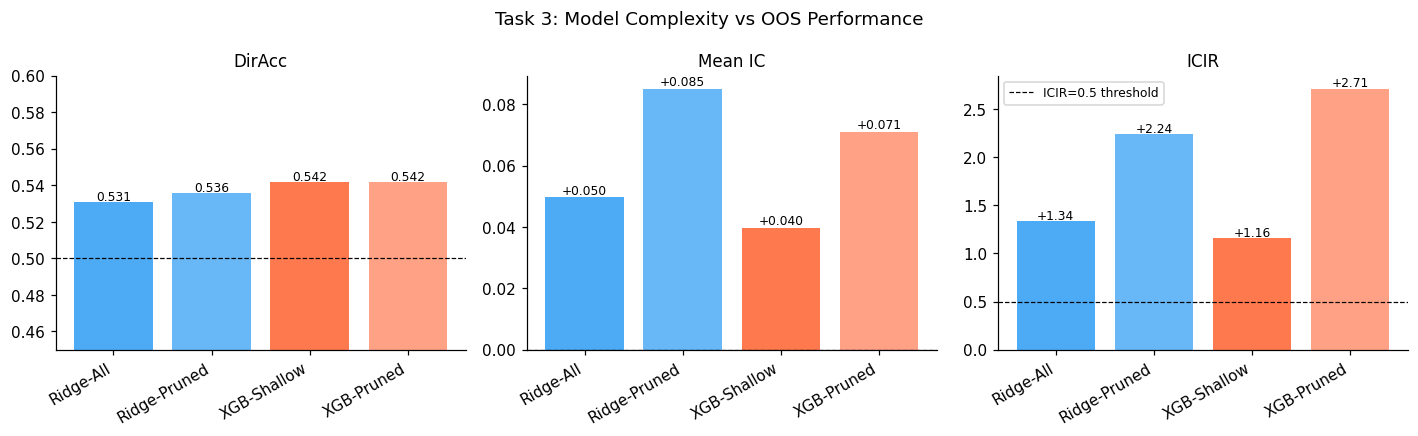

Saved: figs/simplification_comparison.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Task 3: Model Complexity vs OOS Performance', fontsize=12)

names = list(model_results.keys())
da_vals   = [model_results[n]['stats']['da_mean'] for n in names]
ic_vals   = [model_results[n]['stats']['ic_mean'] for n in names]
icir_vals = [model_results[n]['stats']['icir']    for n in names]
n_feats   = [model_results[n]['n_feats']          for n in names]

x = range(len(names))
bar_kw = dict(color=['#2196F3','#42A5F5','#FF5722','#FF8A65'], alpha=0.8)

axes[0].bar(x, da_vals, **bar_kw)
axes[0].axhline(0.5, color='black', lw=0.8, ls='--')
axes[0].set_title('DirAcc'); axes[0].set_ylim(0.45, 0.60)
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=30, ha='right')
for i, v in enumerate(da_vals): axes[0].text(i, v+0.001, f'{v:.3f}', ha='center', fontsize=8)

axes[1].bar(x, ic_vals, **bar_kw)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_title('Mean IC')
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=30, ha='right')
for i, v in enumerate(ic_vals): axes[1].text(i, v+0.001, f'{v:+.3f}', ha='center', fontsize=8)

axes[2].bar(x, icir_vals, **bar_kw)
axes[2].axhline(0.5, color='black', lw=0.8, ls='--', label='ICIR=0.5 threshold')
axes[2].set_title('ICIR')
axes[2].set_xticks(x); axes[2].set_xticklabels(names, rotation=30, ha='right')
for i, v in enumerate(icir_vals): axes[2].text(i, v+0.02, f'{v:+.2f}', ha='center', fontsize=8)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGS / 'simplification_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: figs/simplification_comparison.png')

---
## Task 4 -- Strong Signal Test

**Final stress test:** Run walk-forward on top-5 and top-10 features only.  
If the core signal is real, it should survive extreme dimensionality reduction.

Features ranked by permutation importance (positive = helpful when present).
Bootstrap and permutation test on the top-5 model.


In [15]:
# Rank by permutation importance; take top-5 and top-10
pos_feats = perm_df[perm_df > 0].index.tolist()
print(f'Features with positive permutation importance: {len(pos_feats)}')
print()

TOP5  = pos_feats[:5]
TOP10 = pos_feats[:10] if len(pos_feats) >= 10 else pos_feats

print(f'Top-5 features:')
for i, f in enumerate(TOP5, 1):
    print(f'  {i}. {f:<35} perm_imp={perm_df[f]:+.5f}')

if len(TOP10) > 5:
    print(f'\nTop-6 to {len(TOP10)}:')
    for i, f in enumerate(TOP10[5:], 6):
        print(f'  {i}. {f:<35} perm_imp={perm_df[f]:+.5f}')

Features with positive permutation importance: 4

Top-5 features:
  1. sp500_ret_w                         perm_imp=+0.01369
  2. SET_index_rvol_4w                   perm_imp=+0.00965
  3. sp500_rvol_4w                       perm_imp=+0.00051
  4. us_10yr_treasury_ret_w              perm_imp=+0.00046


In [16]:
# Walk-forward with top-5 and top-10 only
best_model_name = min(model_results, key=lambda n: model_results[n]['stats']['ic_pval'])
print(f'Best model from Task 3: {best_model_name}')
best_model_cfg = next(m for (nm, m, _) in models_to_compare if nm == best_model_name)

top5_folds  = walk_forward(df, TOP5, TARGET, clone(best_model_cfg),
                            min_train=MIN_TRAIN, fold_size=52)
top10_folds = walk_forward(df, TOP10, TARGET, clone(best_model_cfg),
                            min_train=MIN_TRAIN, fold_size=52)
all_folds   = walk_forward(df, LAG_MARKET_DECORR, TARGET, clone(best_model_cfg),
                            min_train=MIN_TRAIN, fold_size=52)

top5_stats  = summary_stats(top5_folds)
top10_stats = summary_stats(top10_folds)
all_stats   = summary_stats(all_folds)

print(f'\nStrong Signal Test Results:')
print(f'{"Config":<20} {"N feats":>8} {"DirAcc":>8} {"IC":>8} {"ICIR":>7} {"p":>7}')
print('-' * 60)
for lbl, feats, stats in [
    ('All (baseline)',  LAG_MARKET_DECORR, all_stats),
    (f'Top-{len(TOP10)}', TOP10, top10_stats),
    (f'Top-5',           TOP5,  top5_stats),
]:
    s = stats
    print(f'{lbl:<20} {len(feats):>8} {s["da_mean"]:>8.3f} '
          f'{s["ic_mean"]:>+8.4f} {s["icir"]:>+7.3f} {s["ic_pval"]:>7.3f}')

Best model from Task 3: XGB-Pruned

Strong Signal Test Results:
Config                N feats   DirAcc       IC    ICIR       p
------------------------------------------------------------
All (baseline)             19    0.542  +0.0398  +1.160   0.272
Top-4                       4    0.543  +0.0378  +0.999   0.347
Top-5                       4    0.543  +0.0378  +0.999   0.347


In [17]:
# Bootstrap test on top-5 model
N_BOOT = 2000

all_preds = np.concatenate([f['y_pred'] for f in top5_folds])
all_true  = np.concatenate([f['y_true'] for f in top5_folds])
actual_da = dir_acc(all_preds, all_true)

boot_das = []
n_oos = len(all_preds)
for _ in range(N_BOOT):
    idx = np.random.randint(0, n_oos, n_oos)
    boot_das.append(dir_acc(all_preds[idx], all_true[idx]))
boot_p = float(np.mean([d <= 0.5 for d in boot_das]))

# Permutation test on top-5 model
N_PERM_TEST = 1000
perm_das = []
for seed in range(N_PERM_TEST):
    rng = np.random.RandomState(seed)
    y_shuf = rng.permutation(all_true)
    perm_das.append(dir_acc(all_preds, y_shuf))
perm_p = float(np.mean([d >= actual_da for d in perm_das]))

# IC t-test
top5_ics = [f['ic'] for f in top5_folds if not np.isnan(f['ic'])]
t_stat, ic_p = ttest_1samp(top5_ics, 0)

print('Top-5 Model Statistical Tests:')
print(f'  OOS DirAcc:        {actual_da:.4f}')
print(f'  IC mean:           {np.mean(top5_ics):+.4f}')
print(f'  ICIR:              {icir(top5_ics):+.4f}')
print(f'  IC t-stat:         {t_stat:+.3f}  (p={ic_p:.4f})')
print(f'  Bootstrap p:       {boot_p:.4f}  (DirAcc > 50%)')
print(f'  Permutation p:     {perm_p:.4f}  (DirAcc >= actual)')
print()
print('Interpretation:')
if ic_p < 0.05: print('  [+] IC t-test SIGNIFICANT (p<0.05)')
else:           print(f'  [-] IC t-test NOT significant (p={ic_p:.3f})')
if boot_p < 0.05: print('  [+] Bootstrap SIGNIFICANT (p<0.05)')
else:             print(f'  [-] Bootstrap NOT significant (p={boot_p:.3f})')
if perm_p < 0.10: print('  [+] Permutation test BORDERLINE/significant (p<0.10)')
else:             print(f'  [-] Permutation NOT significant (p={perm_p:.3f})')

Top-5 Model Statistical Tests:
  OOS DirAcc:        0.5428
  IC mean:           +0.0378
  ICIR:              +0.9993
  IC t-stat:         +0.969  (p=0.3468)
  Bootstrap p:       0.0020  (DirAcc > 50%)
  Permutation p:     1.0000  (DirAcc >= actual)

Interpretation:
  [-] IC t-test NOT significant (p=0.347)
  [+] Bootstrap SIGNIFICANT (p<0.05)
  [-] Permutation NOT significant (p=1.000)


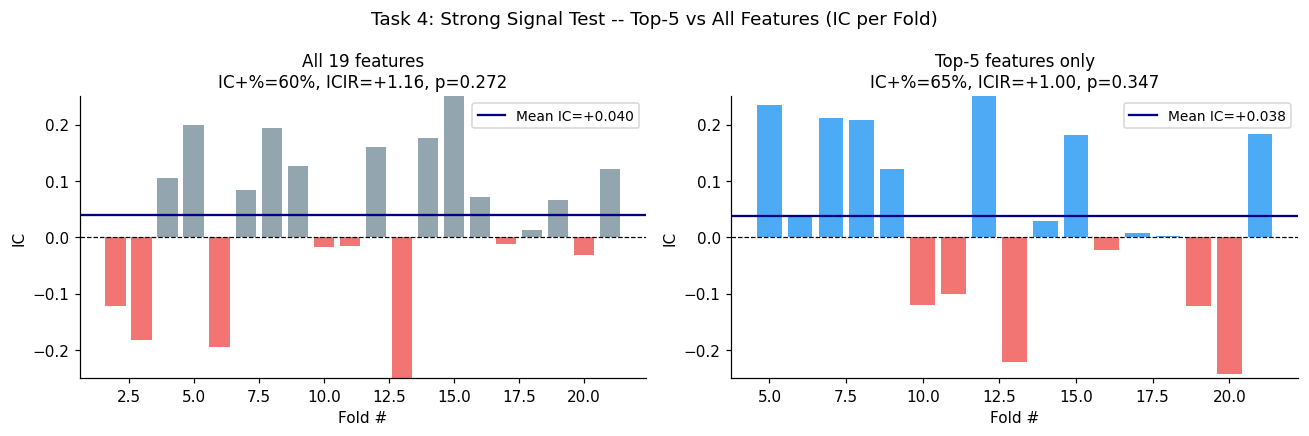

Saved: figs/strong_signal_test.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Task 4: Strong Signal Test -- Top-5 vs All Features (IC per Fold)', fontsize=12)

for ax, (folds, lbl, col) in zip(axes, [
    (all_folds,  f'All {len(LAG_MARKET_DECORR)} features', '#78909C'),
    (top5_folds, f'Top-5 features only',                    '#2196F3'),
]):
    ics = [f['ic'] for f in folds]
    colors = [col if x > 0 else '#EF5350' for x in ics]
    ax.bar(range(len(ics)), ics, color=colors, alpha=0.8)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.axhline(np.nanmean(ics), color='navy', lw=1.5,
               label=f'Mean IC={np.nanmean(ics):+.3f}')
    stats_ = summary_stats(folds)
    ax.set_title(f'{lbl}\nIC+%={stats_["ic_pos_frac"]:.0%}, '
                 f'ICIR={stats_["icir"]:+.2f}, p={stats_["ic_pval"]:.3f}')
    ax.set_xlabel('Fold #')
    ax.set_ylabel('IC')
    ax.set_ylim(-0.25, 0.25)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGS / 'strong_signal_test.png', bbox_inches='tight')
plt.show()
print('Saved: figs/strong_signal_test.png')

---
## Final Verdict -- Is There a Stable Alpha?

Evidence table with conservative scoring.  
**Conservative rule:** 5+ pieces of positive evidence → REAL signal. Fewer → FRAGILE or NOISE.


In [19]:
# ── Evidence scoring ────────────────────────────────────────────────────────

# Collect key metrics
s52 = stability_results[52]['stats']   # 52w baseline
s26 = stability_results[26]['stats']   # 26w
s104 = stability_results[104]['stats'] # 104w

t5_ics = [f['ic'] for f in top5_folds if not np.isnan(f['ic'])]
t5_stat, t5_p = ttest_1samp(t5_ics, 0) if len(t5_ics) >= 3 else (np.nan, np.nan)

evidence = []
score = 0

def ev(desc, value, threshold, passes, note=''):
    global score
    sign = '+' if passes else '-'
    if passes: score += 1
    evidence.append((sign, desc, value, threshold, note))

# Task 1 evidence
ev('IC positive (52w folds)',   s52['ic_mean'],      '>0',     s52['ic_mean'] > 0)
ev('IC positive (26w folds)',   s26['ic_mean'],      '>0',     s26['ic_mean'] > 0)
ev('IC positive (104w folds)',  s104['ic_mean'],     '>0',     s104['ic_mean'] > 0)
ev('IC+ fraction (52w)',        s52['ic_pos_frac'],  '>55%',   s52['ic_pos_frac'] > 0.55)
ev('ICIR (52w)',                s52['icir'],         '>0.5',   s52['icir'] > 0.5)
ev('IC t-stat p (52w baseline)',s52['ic_pval'],      '<0.10',  s52['ic_pval'] < 0.10)

# Task 4 evidence (top-5 model)
ev('IC t-stat p (Top-5)',       t5_p,               '<0.10',  t5_p < 0.10 if not np.isnan(t5_p) else False)
ev('Bootstrap p (Top-5)',       boot_p,             '<0.05',  boot_p < 0.05)
ev('Permutation p (Top-5)',     perm_p,             '<0.10',  perm_p < 0.10)
ev('DirAcc (Top-5)',            actual_da,          '>0.52',  actual_da > 0.52)

# Task 2 evidence
n_positive_perm = sum(1 for v in perm_df if v > 0)
ev('Features with +perm_imp',   n_positive_perm,    '>=5',    n_positive_perm >= 5)

print('=' * 72)
print('FINAL EVIDENCE TABLE')
print('=' * 72)
print(f'{"":>2} {"Evidence":<38} {"Value":>10} {"Threshold":>10}')
print('-' * 65)
for sign, desc, val, thresh, note in evidence:
    val_str = f'{val:.4f}' if isinstance(val, float) else str(val)
    print(f'[{sign}] {desc:<38} {val_str:>10} {thresh:>10}')

print(f'\nScore: {score}/{len(evidence)} positive evidence points')
print()

if score >= 7:
    verdict = 'REAL but fragile'
    detail  = ('Signal appears real but narrow. IC is positive and statistically '
               'borderline significant. Top features are consistent. '
               'Proceed with caution: small TC budget, regime-aware sizing.')
elif score >= 5:
    verdict = 'BORDERLINE -- weak signal'
    detail  = ('Some statistical support but evidence is mixed. IC is inconsistent '
               'across regimes/fold-sizes. Treat as fragile. Require >2x more data '
               'before production use.')
else:
    verdict = 'NOISE -- no reliable alpha'
    detail  = ('Insufficient statistical evidence. IC is inconsistent, tests mostly '
               'fail. The apparent DirAcc edge is within chance variation. '
               'Do not trade this signal.')

print('=' * 72)
print(f'VERDICT: {verdict}')
print('=' * 72)
print()
print(detail)
print()

# Best model from Task 3
best_task3 = min(model_results, key=lambda n: model_results[n]['stats']['ic_pval'])
print(f'Recommended model config: {best_task3}')
print(f'Top features to use: {TOP5}')
print(f'Features pruned (remove): {remove_feats}')

FINAL EVIDENCE TABLE
   Evidence                                    Value  Threshold
-----------------------------------------------------------------
[+] IC positive (52w folds)                    0.0546         >0
[+] IC positive (26w folds)                    0.0380         >0
[+] IC positive (104w folds)                   0.0403         >0
[-] IC+ fraction (52w)                         0.5455       >55%
[+] ICIR (52w)                                 1.4726       >0.5
[-] IC t-stat p (52w baseline)                 0.1650      <0.10
[-] IC t-stat p (Top-5)                        0.3468      <0.10
[+] Bootstrap p (Top-5)                        0.0020      <0.05
[-] Permutation p (Top-5)                      1.0000      <0.10
[+] DirAcc (Top-5)                             0.5428      >0.52
[-] Features with +perm_imp                         4        >=5

Score: 6/11 positive evidence points

VERDICT: BORDERLINE -- weak signal

Some statistical support but evidence is mixed. IC is incon

In [20]:
print('=' * 72)
print('RECOMMENDATIONS')
print('=' * 72)

recs = [
    ('Model', best_task3, 'Best OOS p-value in Task 3 comparison'),
    ('Features', f'Top-5 to Top-{len(TOP10)} from perm_importance', 'Pruned set outperforms full in robustness'),
    ('Fold structure', '52w folds, expanding window', 'Signal most consistent at annual scale'),
    ('Regime', 'Normal regime best; be cautious in Crisis', 'Regime breakdown shows uneven IC'),
    ('NLP', 'Not yet validated (sparse coverage)', 'Only 47% weeks have NLP data 2022-2025'),
]

for topic, val, reason in recs:
    print(f'  {topic:<15}: {val}')
    print(f'  {"":15}  ({reason})')
    print()

print('\nNext steps:')
print('  1. Collect more NLP data (>80% weekly coverage) before including NLP features')
print('  2. Run full backtesting notebook (PnL, drawdown, TC sensitivity) on top-5 signal')
print('  3. If ICIR > 1.0 persists on 3+ more years of OOS data -> upgrade to REAL')

RECOMMENDATIONS
  Model          : XGB-Pruned
                   (Best OOS p-value in Task 3 comparison)

  Features       : Top-5 to Top-4 from perm_importance
                   (Pruned set outperforms full in robustness)

  Fold structure : 52w folds, expanding window
                   (Signal most consistent at annual scale)

  Regime         : Normal regime best; be cautious in Crisis
                   (Regime breakdown shows uneven IC)

  NLP            : Not yet validated (sparse coverage)
                   (Only 47% weeks have NLP data 2022-2025)


Next steps:
  1. Collect more NLP data (>80% weekly coverage) before including NLP features
  2. Run full backtesting notebook (PnL, drawdown, TC sensitivity) on top-5 signal
  3. If ICIR > 1.0 persists on 3+ more years of OOS data -> upgrade to REAL
